In [1]:
import sys
sys.path.append('../')

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from data_loader import PairData
from env_v2_07 import PairTradingEnv
from ddqn import DoubleDQN

SEED = 42
rng  = np.random.default_rng(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
# ── Data & split ─────────────────────────────────────────────────────────
data   = PairData('../../data/real_pair_MCD_YUM.csv')
prices = data.s
N      = prices.shape[1]

train_end = 3 * N // 4

log_A = np.log(prices[0])
log_B = np.log(prices[1])

LOOKBACK = 252   # estimation window (1 trading year)

def fit_window(t0):
    """OLS on [t0-LOOKBACK, t0) → (beta, intercept, z_mean, z_std)."""
    A = log_A[t0 - LOOKBACK : t0]
    B = log_B[t0 - LOOKBACK : t0]
    X = np.column_stack([np.ones(LOOKBACK), B])
    coef, _, _, _ = np.linalg.lstsq(X, A, rcond=None)
    icp, b = float(coef[0]), float(coef[1])
    spread = A - b * B - icp
    return b, icp, float(spread.mean()), float(spread.std())

print(f'N={N}  |  train [0, {train_end})  |  test [{train_end}, {N})')
print(f'LOOKBACK={LOOKBACK}  →  first valid t0={LOOKBACK}')

N=5032  |  train [0, 3774)  |  test [3774, 5032)
LOOKBACK=252  →  first valid t0=252


In [3]:
# ── Episode setup — real windows only ────────────────────────────────────
EPISODE_LEN = 252
EP_LEN_FULL = 3 + EPISODE_LEN   # 255: 3-step vel warmup + 252 tradeable steps

REAL_T_MIN = LOOKBACK                    # need prior year for OLS
REAL_T_MAX = train_end - EP_LEN_FULL     # latest valid start in train set

def sample_real(t0):
    """Slice (2, EP_LEN_FULL) real prices starting at t0."""
    return prices[:, t0 : t0 + EP_LEN_FULL]

print(f'Episode length : {EPISODE_LEN} steps  |  slice: {EP_LEN_FULL} pts')
print(f'Train start range: [{REAL_T_MIN}, {REAL_T_MAX}]  ({REAL_T_MAX - REAL_T_MIN + 1} options)')

Episode length : 252 steps  |  slice: 255 pts
Train start range: [252, 3519]  (3268 options)


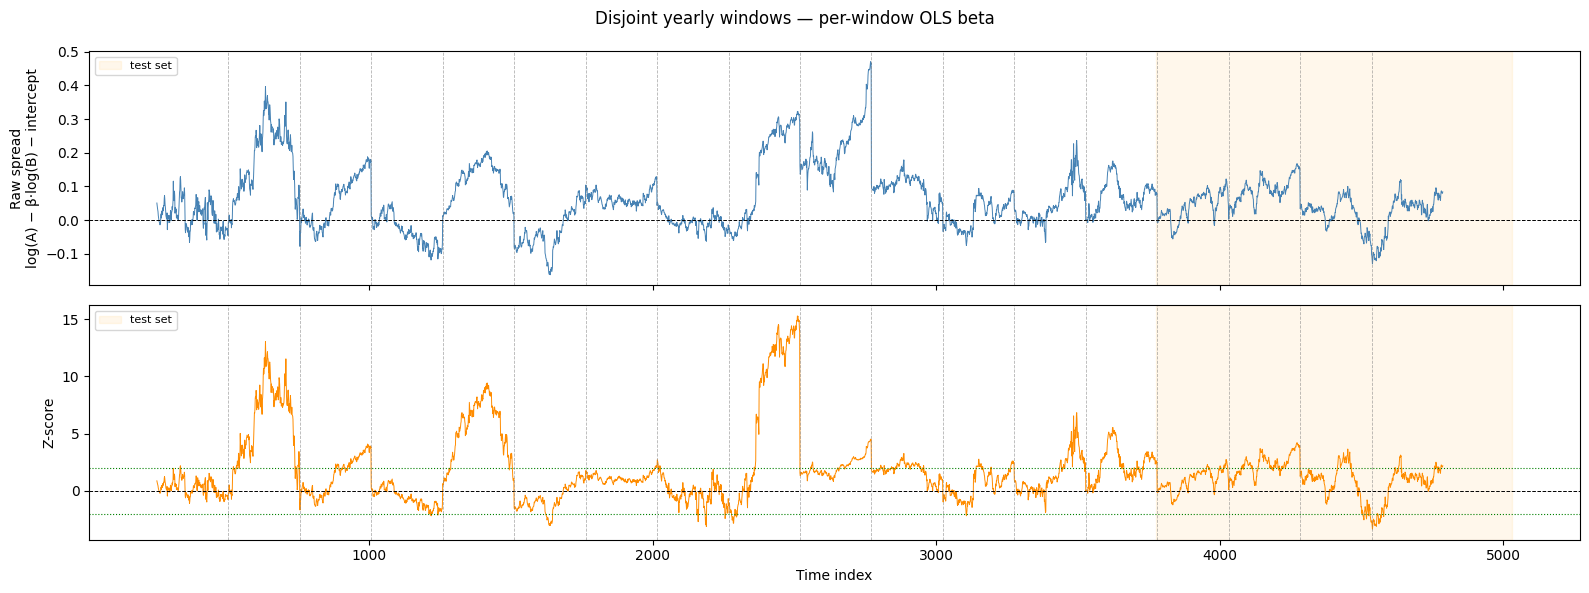

In [4]:
# ── Full-dataset spread: disjoint yearly windows, each normalised by prior year
# Windows: [LOOKBACK, LOOKBACK+252), [LOOKBACK+252, LOOKBACK+504), ...
# Each window uses [t0-LOOKBACK, t0) for OLS → (beta, intercept, z_mean, z_std)

z_concat  = []
s_concat  = []   # raw spread (demeaned by prior-year intercept)
t_concat  = []
win_edges = []

t0 = LOOKBACK
while t0 + EPISODE_LEN <= N:
    b, icp, zm, zs = fit_window(t0)
    t1     = min(t0 + EPISODE_LEN, N)
    spread = log_A[t0:t1] - b * log_B[t0:t1] - icp
    z      = (spread - zm) / zs
    z_concat.append(z)
    s_concat.append(spread)
    t_concat.append(np.arange(t0, t1))
    win_edges.append(t0)
    t0 = t1

z_all = np.concatenate(z_concat)
s_all = np.concatenate(s_concat)
t_all = np.concatenate(t_concat)

def _add_overlays(ax):
    for edge in win_edges[1:]:
        ax.axvline(edge, color='gray', lw=0.6, ls='--', alpha=0.6)
    ax.axvspan(train_end, N, alpha=0.08, color='orange', label='test set')
    ax.legend(fontsize=8)

fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)
fig.suptitle('Disjoint yearly windows — per-window OLS beta', fontsize=12)

ax = axes[0]
ax.plot(t_all, s_all, color='steelblue', lw=0.7)
ax.axhline(0, color='black', lw=0.7, ls='--')
ax.set_ylabel('Raw spread\nlog(A) − β·log(B) − intercept')
_add_overlays(ax)

ax = axes[1]
ax.plot(t_all, z_all, color='darkorange', lw=0.7)
ax.axhline( 0,   color='black', lw=0.7, ls='--')
ax.axhline( 2.0, color='green', lw=0.8, ls=':')
ax.axhline(-2.0, color='green', lw=0.8, ls=':')
ax.set_ylabel('Z-score')
ax.set_xlabel('Time index')
_add_overlays(ax)

plt.tight_layout()
plt.show()

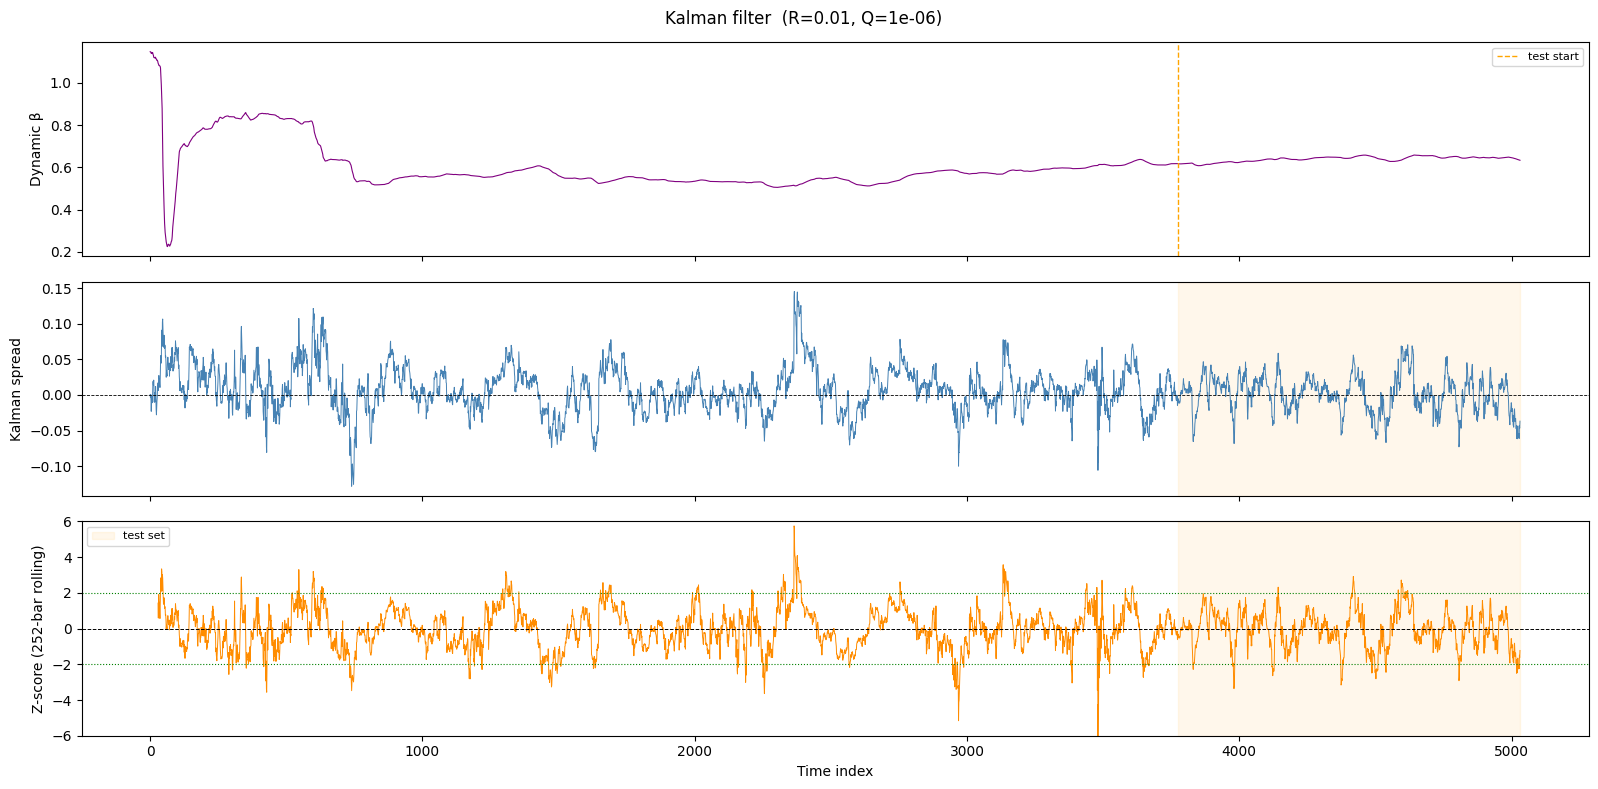

In [5]:
# ── Kalman filter — dynamic beta & intercept ─────────────────────────────
# State x = [beta, intercept], evolves as random walk.
# Observation: log_A_t = [log_B_t, 1] @ x_t + noise

R = 1e-2    # observation noise variance
Q = 1e-6    # process noise per step (larger = beta drifts faster)

x = np.array([1.0, 0.0])
P = np.eye(2) * 1.0
I2 = np.eye(2)

kf_beta      = np.zeros(N)
kf_intercept = np.zeros(N)
kf_spread    = np.zeros(N)

for t in range(N):
    H = np.array([log_B[t], 1.0])
    P = P + Q * I2
    innov = log_A[t] - H @ x
    S     = H @ P @ H + R
    K     = (P @ H) / S
    x     = x + K * innov
    P     = (I2 - np.outer(K, H)) @ P
    kf_beta[t]      = x[0]
    kf_intercept[t] = x[1]
    kf_spread[t]    = log_A[t] - x[0] * log_B[t] - x[1]

# Rolling z-score of Kalman spread (252-bar window)
kf_s  = pd.Series(kf_spread)
roll  = kf_s.rolling(252, min_periods=30)
kf_z  = ((kf_s - roll.mean()) / roll.std()).values

def fit_window_kf(t0):
    """Use Kalman beta/intercept at t0-1, z stats from prior LOOKBACK window."""
    b   = float(kf_beta[t0 - 1])
    icp = float(kf_intercept[t0 - 1])
    spread = log_A[t0 - LOOKBACK : t0] - b * log_B[t0 - LOOKBACK : t0] - icp
    return b, icp, float(spread.mean()), float(spread.std())

fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)
fig.suptitle(f'Kalman filter  (R={R}, Q={Q})', fontsize=12)

axes[0].plot(kf_beta, color='purple', lw=0.8)
axes[0].set_ylabel('Dynamic β')
axes[0].axvline(train_end, color='orange', lw=1, ls='--', label='test start')
axes[0].legend(fontsize=8)

axes[1].plot(kf_spread, color='steelblue', lw=0.7)
axes[1].axhline(0, color='black', lw=0.6, ls='--')
axes[1].axvspan(train_end, N, alpha=0.08, color='orange')
axes[1].set_ylabel('Kalman spread')

axes[2].plot(kf_z, color='darkorange', lw=0.7)
axes[2].axhline( 0,   color='black', lw=0.7, ls='--')
axes[2].axhline( 2.0, color='green', lw=0.8, ls=':')
axes[2].axhline(-2.0, color='green', lw=0.8, ls=':')
axes[2].axvspan(train_end, N, alpha=0.08, color='orange', label='test set')
axes[2].set_ylabel('Z-score (252-bar rolling)')
axes[2].set_xlabel('Time index')
axes[2].set_ylim(-6, 6)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

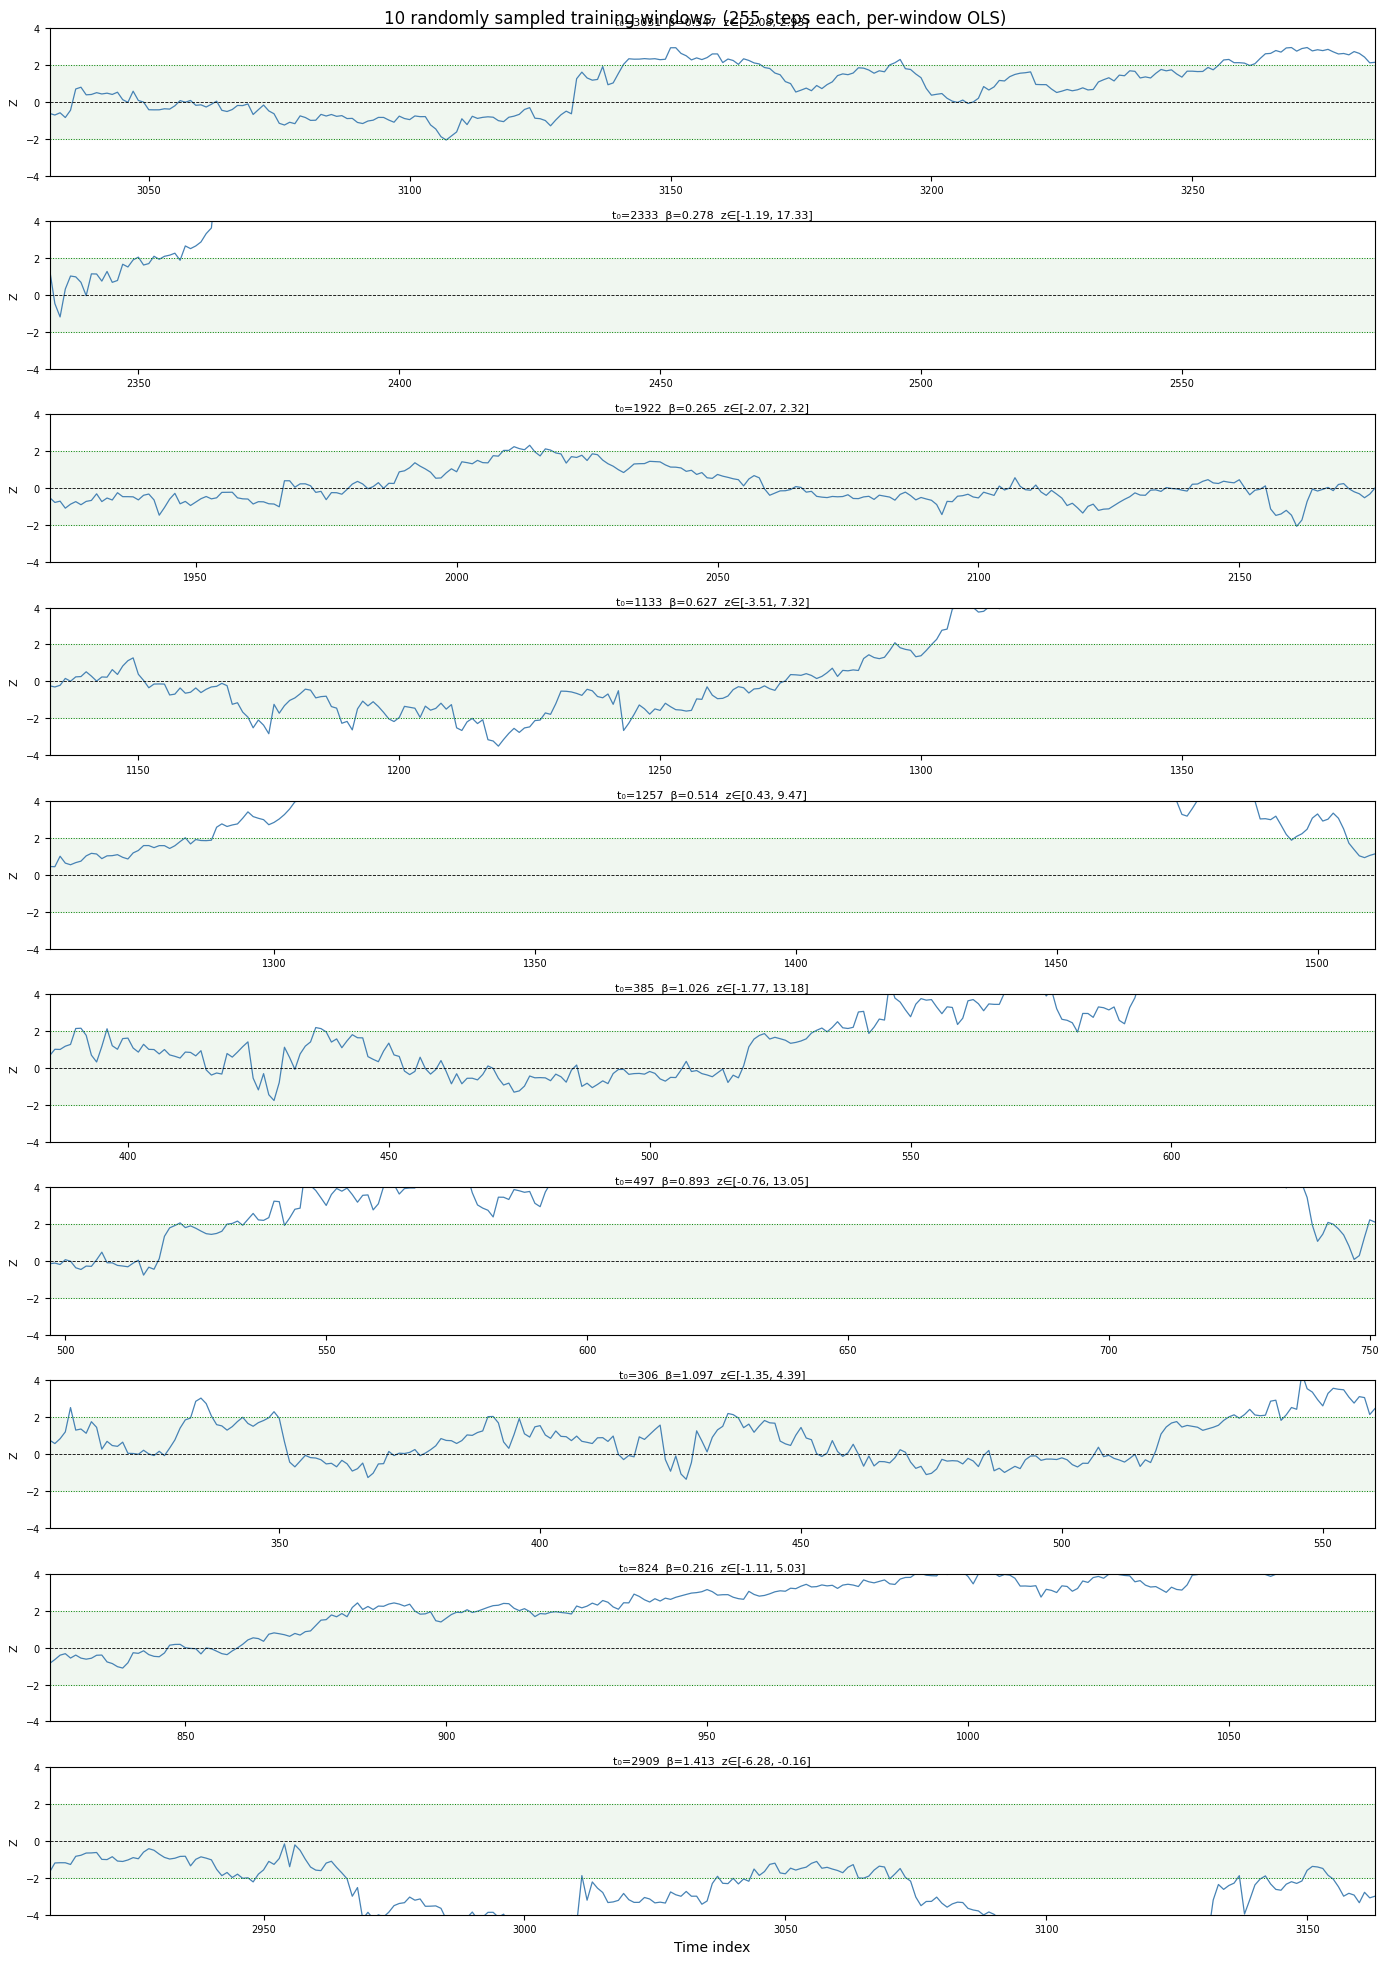

In [6]:
# ── Visualise 10 training windows (stacked top-to-bottom) ────────────────
N_SHOW  = 10
rng_vis = np.random.default_rng(0)

t0_list = [int(rng_vis.integers(REAL_T_MIN, REAL_T_MAX + 1)) for _ in range(N_SHOW)]

fig, axes = plt.subplots(N_SHOW, 1, figsize=(14, N_SHOW * 2.0), sharex=False)
fig.suptitle(f'{N_SHOW} randomly sampled training windows  ({EP_LEN_FULL} steps each, per-window OLS)', fontsize=12)

for ax, t0 in zip(axes, t0_list):
    b, icp, zm, zs = fit_window(t0)
    spread_ep = log_A[t0 : t0 + EP_LEN_FULL] - b * log_B[t0 : t0 + EP_LEN_FULL] - icp
    z_ep      = (spread_ep - zm) / zs
    t_idx     = np.arange(t0, t0 + EP_LEN_FULL)

    ax.plot(t_idx, z_ep, color='steelblue', lw=0.9)
    ax.fill_between(t_idx, -2, 2, alpha=0.06, color='green')
    ax.axhline( 0,   color='black', lw=0.6, ls='--')
    ax.axhline( 2.0, color='green', lw=0.7, ls=':')
    ax.axhline(-2.0, color='green', lw=0.7, ls=':')
    ax.set_xlim(t0, t0 + EP_LEN_FULL - 1)
    ax.set_ylim(-4, 4)
    ax.set_ylabel('Z', fontsize=8)
    ax.set_title(f't₀={t0}  β={b:.3f}  z∈[{z_ep.min():.2f}, {z_ep.max():.2f}]', fontsize=8, pad=2)
    ax.tick_params(labelsize=7)

axes[-1].set_xlabel('Time index')
plt.tight_layout()
plt.show()

In [7]:
# ── Agent ─────────────────────────────────────────────────────────────────
agent = DoubleDQN(
    state_dim       = 4,
    action_dim      = 3,
    hidden          = 64,
    lr              = 3e-4,
    gamma           = 0.99,
    tau             = 0.005,
    buffer_size     = int(1e6),
    batch_size      = 256,
    eps_start       = 1.0,
    eps_end         = 0.05,
    eps_decay_steps = 800_000,
    grad_clip       = 1.0,
)
print(f'Agent ready.  Initial epsilon: {agent.epsilon:.3f}')

Agent ready.  Initial epsilon: 1.000


In [8]:
# ── Training loop — real data, Kalman beta ───────────────────────────────
N_EPISODES  = 1200
TRAIN_FREQ  = 4
LOG_EVERY   = 100

ep_rewards  = []
ep_wealth   = []
ep_eps      = []
losses      = []
total_steps = 0

for ep in range(N_EPISODES):
    t0 = int(rng.integers(REAL_T_MIN, REAL_T_MAX + 1))
    beta_ep, intercept_ep, z_mean_ep, z_std_ep = fit_window_kf(t0)
    prices_ep = sample_real(t0)
    env = PairTradingEnv(prices_ep,
                         beta=beta_ep, intercept=intercept_ep,
                         z_mean=z_mean_ep, z_std=z_std_ep,
                         episode_len=EPISODE_LEN)

    obs, _ = env.reset()
    done   = False
    ep_r   = 0.0

    while not done:
        action = agent.select_action(obs)
        next_obs, reward, done, _, _ = env.step(action)
        agent.replay_buffer.add(obs, action, reward, next_obs, done)
        obs  = next_obs
        ep_r += reward
        total_steps += 1

        if total_steps % TRAIN_FREQ == 0:
            loss = agent.train()
            if loss is not None:
                losses.append(loss)

    ep_rewards.append(ep_r)
    ep_wealth.append(env._wealth())
    ep_eps.append(agent.epsilon)

    if (ep + 1) % LOG_EVERY == 0:
        avg_r = np.mean(ep_rewards[-LOG_EVERY:])
        avg_w = np.mean(ep_wealth[-LOG_EVERY:])
        print(f'ep {ep+1:5d} | avg_reward {avg_r:+8.2f} | avg_wealth {avg_w:8.2f} | '
              f'eps {agent.epsilon:.3f}')

ep   100 | avg_reward  +214.23 | avg_wealth 10214.23 | eps 0.970
ep   200 | avg_reward  +302.83 | avg_wealth 10302.83 | eps 0.940
ep   300 | avg_reward  +304.56 | avg_wealth 10304.56 | eps 0.910
ep   400 | avg_reward  +340.75 | avg_wealth 10340.75 | eps 0.880
ep   500 | avg_reward  +619.92 | avg_wealth 10619.92 | eps 0.850
ep   600 | avg_reward  +526.85 | avg_wealth 10526.85 | eps 0.820
ep   700 | avg_reward  +450.18 | avg_wealth 10450.18 | eps 0.791
ep   800 | avg_reward  +650.51 | avg_wealth 10650.51 | eps 0.761
ep   900 | avg_reward  +609.05 | avg_wealth 10609.05 | eps 0.731
ep  1000 | avg_reward  +609.36 | avg_wealth 10609.36 | eps 0.701
ep  1100 | avg_reward  +735.81 | avg_wealth 10735.81 | eps 0.671
ep  1200 | avg_reward  +659.10 | avg_wealth 10659.10 | eps 0.641


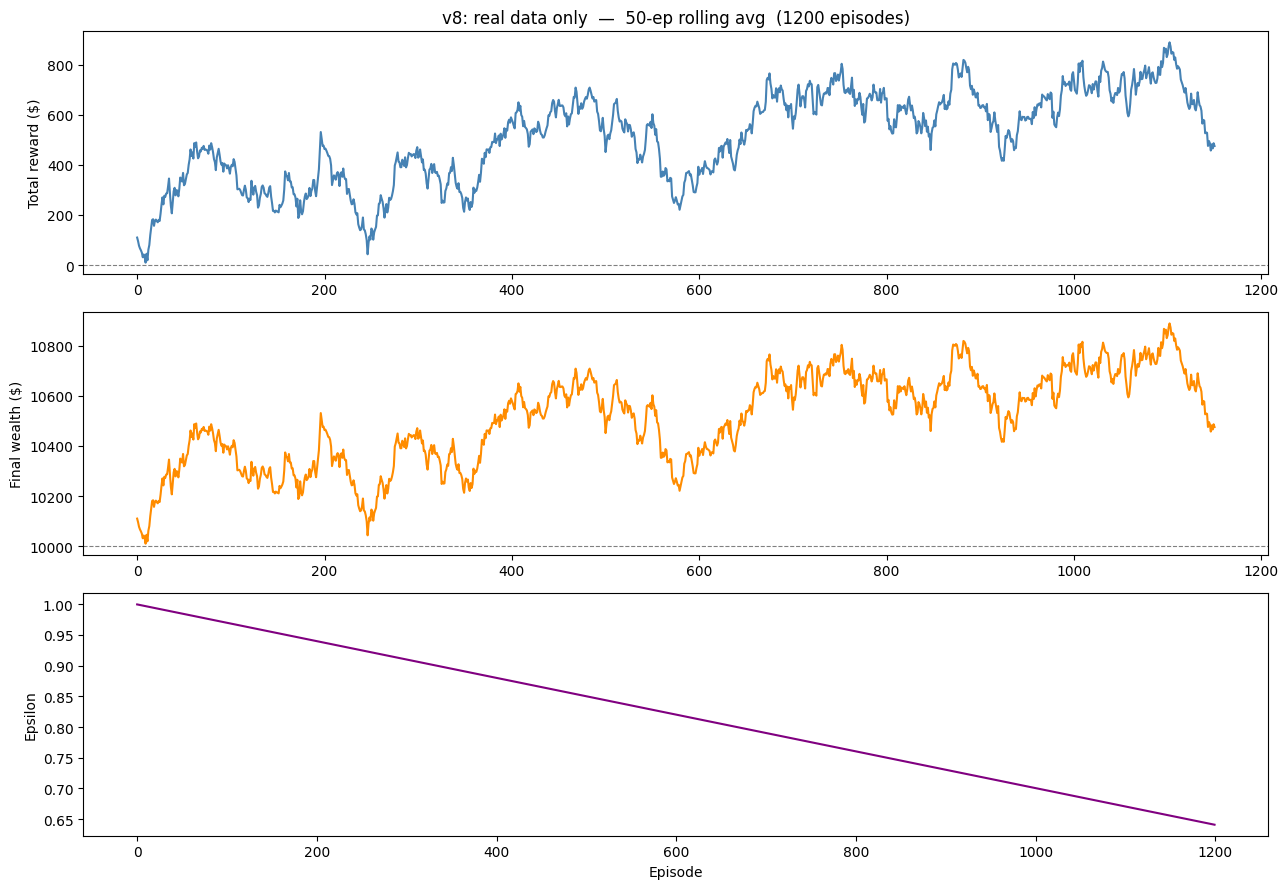

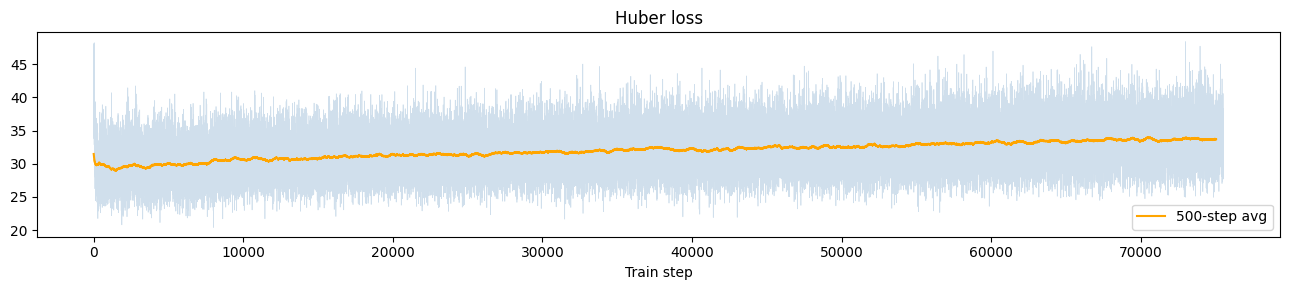

In [9]:
# ── Training curves ──────────────────────────────────────────────────────
roll = 50
kern = np.ones(roll) / roll

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=False)

axes[0].plot(np.convolve(ep_rewards, kern, mode='valid'), color='steelblue')
axes[0].axhline(0, color='gray', lw=0.8, ls='--')
axes[0].set_ylabel('Total reward ($)')
axes[0].set_title(f'v8: real data only  —  {roll}-ep rolling avg  ({N_EPISODES} episodes)')

axes[1].plot(np.convolve(ep_wealth, kern, mode='valid'), color='darkorange')
axes[1].axhline(10_000, color='gray', lw=0.8, ls='--')
axes[1].set_ylabel('Final wealth ($)')

axes[2].plot(ep_eps, color='purple')
axes[2].set_ylabel('Epsilon')
axes[2].set_xlabel('Episode')

plt.tight_layout()
plt.show()

if losses:
    fig, ax = plt.subplots(figsize=(13, 3))
    ax.plot(losses, alpha=0.25, lw=0.5, color='steelblue')
    smooth = np.convolve(losses, np.ones(500)/500, mode='valid')
    ax.plot(smooth, color='orange', lw=1.5, label='500-step avg')
    ax.set_title('Huber loss')
    ax.set_xlabel('Train step')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [10]:
# ── Evaluation helpers ───────────────────────────────────────────────────
_RF_DAILY = (1.05) ** (1.0 / 252) - 1

def evaluate(env, agent, t_start=None, t_end=None):
    if t_start is not None:
        env._t      = t_start
        env._end    = t_end if t_end is not None else env._N
        env._cash   = env.initial_wealth
        env._shares = np.zeros(2, dtype=np.float64)
        env._pos    = 0
        obs         = env._obs()
    else:
        obs, _ = env.reset()

    t0            = env._t
    wealth        = [env._wealth()]
    z_hist        = [float(obs[0])]
    pos_hist      = []
    entries_long  = []
    entries_short = []
    exits         = []
    step          = 0

    done = False
    while not done:
        prev_pos = env._pos
        action   = agent.select_action(obs, deterministic=True)
        obs, reward, done, _, _ = env.step(action)

        pos_hist.append(env._pos)
        wealth.append(env._wealth())
        z_hist.append(float(obs[0]))

        if env._pos != prev_pos:
            if env._pos == 1:
                entries_long.append(step)
            elif env._pos == -1:
                entries_short.append(step)
            else:
                exits.append(step)
        step += 1

    return {
        'wealth':        np.array(wealth),
        'z':             np.array(z_hist),
        'pos':           np.array(pos_hist),
        'entries_long':  entries_long,
        'entries_short': entries_short,
        'exits':         exits,
        't_start':       t0,
    }


def metrics(wealth, label=''):
    W   = np.array(wealth)
    ret = np.diff(W) / W[:-1]
    total_ret = (W[-1] / W[0] - 1.0) * 100
    sharpe    = ret.mean() / (ret.std() + 1e-10) * np.sqrt(252)
    peak      = np.maximum.accumulate(W)
    mdd       = ((W - peak) / peak).min() * 100
    print(f'{label:50s}  final ${W[-1]:8.0f}  ret {total_ret:+6.1f}%  Sharpe {sharpe:5.2f}  MDD {mdd:6.1f}%')
    return {'sharpe': sharpe, 'mdd': mdd, 'total_ret': total_ret}


def plot_results(res, title=''):
    t0      = res['t_start']
    steps   = len(res['z']) - 1
    t_idx   = np.arange(t0, t0 + steps + 1)
    t_idx_p = t_idx[t_idx < prices.shape[1]]

    W         = res['wealth']
    benchmark = W[0] * (1 + _RF_DAILY) ** np.arange(len(W))

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(title, fontsize=12)

    axes[0].plot(t_idx, W,         color='navy', label='strategy')
    axes[0].plot(t_idx, benchmark, color='gray', lw=1, ls='--', label='5% p.a.')
    axes[0].axhline(W[0], color='lightgray', lw=0.6, ls=':')
    axes[0].set_ylabel('Wealth ($)')
    axes[0].legend(fontsize=8)

    axes[1].plot(t_idx_p, prices[0, t_idx_p], label=data.labels[0], alpha=0.8)
    axes[1].plot(t_idx_p, prices[1, t_idx_p], label=data.labels[1], alpha=0.8)
    axes[1].legend(fontsize=8)
    axes[1].set_ylabel('Price ($)')

    ax_z = axes[2]
    ax_z.plot(t_idx, res['z'], color='black', lw=0.8)
    ax_z.axhline(0,    color='gray',  lw=0.8, ls='--')
    ax_z.axhline( 2.0, color='green', lw=0.8, ls=':')
    ax_z.axhline(-2.0, color='green', lw=0.8, ls=':')

    pos_ext = np.concatenate([[0], res['pos']])
    for i in range(len(pos_ext) - 1):
        if pos_ext[i] == 1:
            ax_z.axvspan(t_idx[i], t_idx[i+1], alpha=0.12, color='green')
        elif pos_ext[i] == -1:
            ax_z.axvspan(t_idx[i], t_idx[i+1], alpha=0.12, color='red')

    for i in res['entries_long']:
        ax_z.scatter(t_idx[i], res['z'][i], color='green', s=30, zorder=5)
    for i in res['entries_short']:
        ax_z.scatter(t_idx[i], res['z'][i], color='red',   s=30, zorder=5)
    for i in res['exits']:
        ax_z.scatter(t_idx[i], res['z'][i], color='blue',  s=15, zorder=5)

    n_l = len(res['entries_long']);  n_s = len(res['entries_short'])
    ax_z.set_ylabel('Z-score')
    ax_z.set_xlabel('Time index')
    ax_z.set_title(f'long: {n_l}  |  short: {n_s}  |  exits: {len(res["exits"])}')

    plt.tight_layout()
    plt.show()

=== Test set (5 × 252-bar windows, Kalman beta) ===
Test yr 1  [3774–4026)  β=0.617                     final $    9598  ret   -4.0%  Sharpe -0.55  MDD   -8.7%


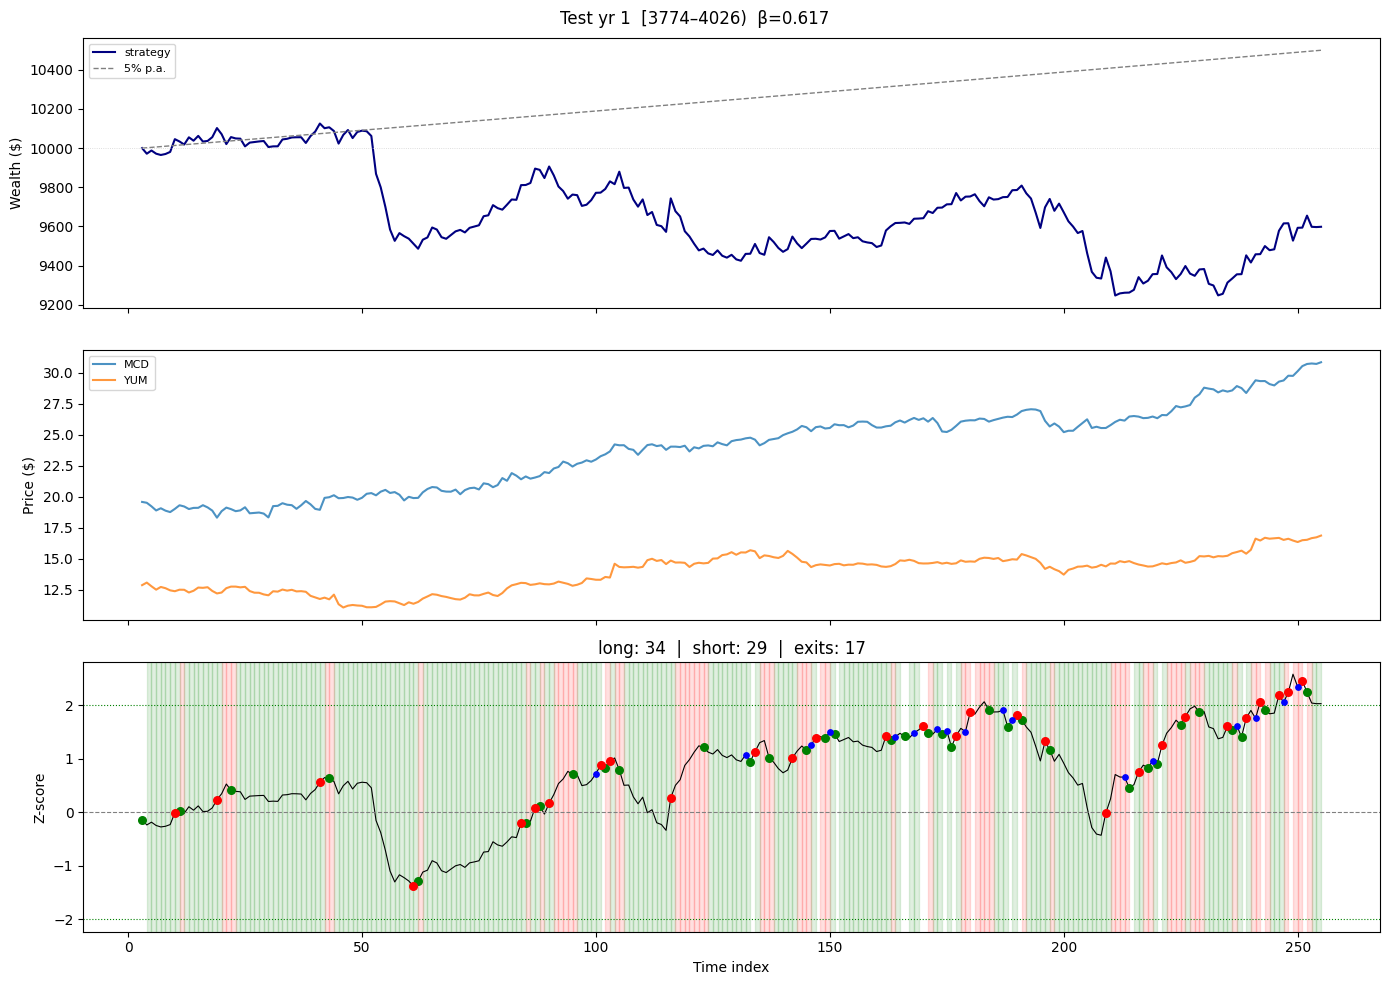

Test yr 2  [4026–4278)  β=0.629                     final $   10837  ret   +8.4%  Sharpe  1.10  MDD   -9.9%


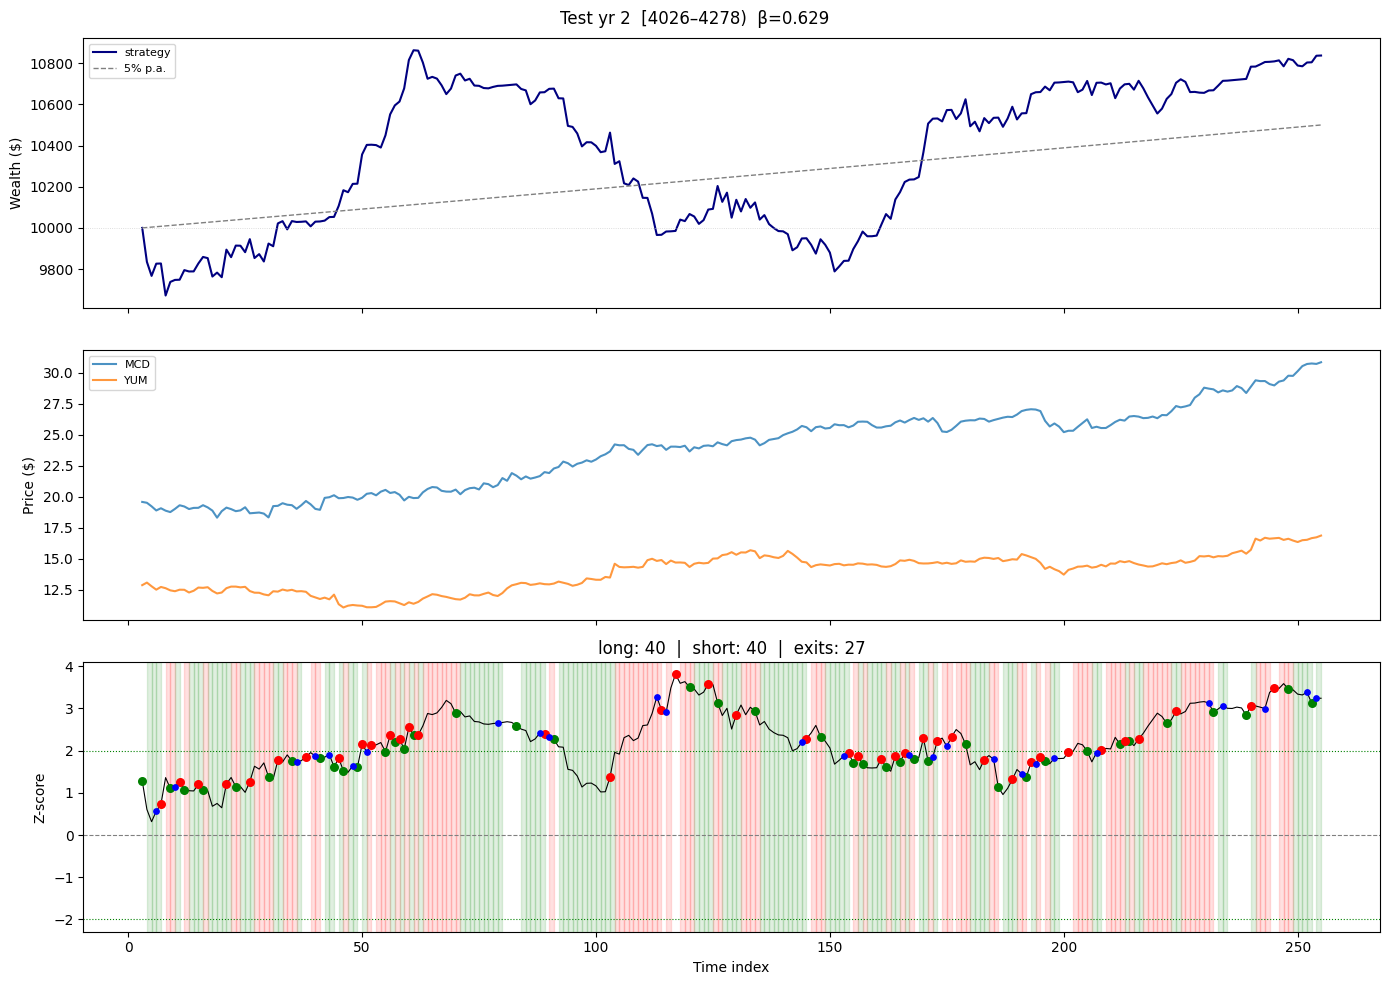

Test yr 3  [4278–4530)  β=0.645                     final $    9660  ret   -3.4%  Sharpe -0.49  MDD  -10.2%


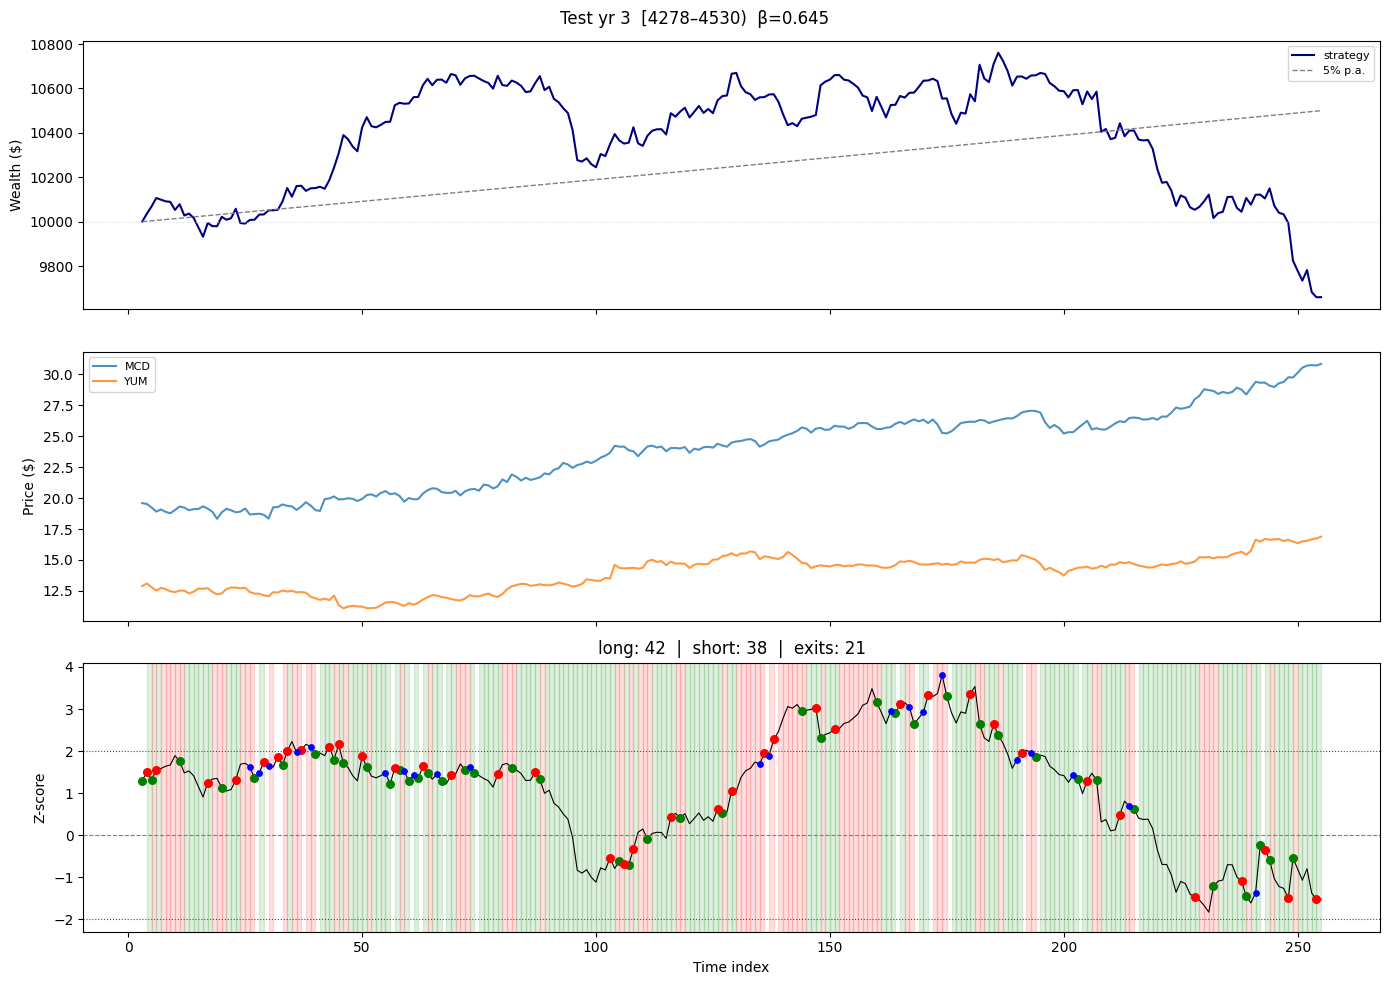

Test yr 4  [4530–4782)  β=0.637                     final $   10796  ret   +8.0%  Sharpe  0.88  MDD   -6.7%


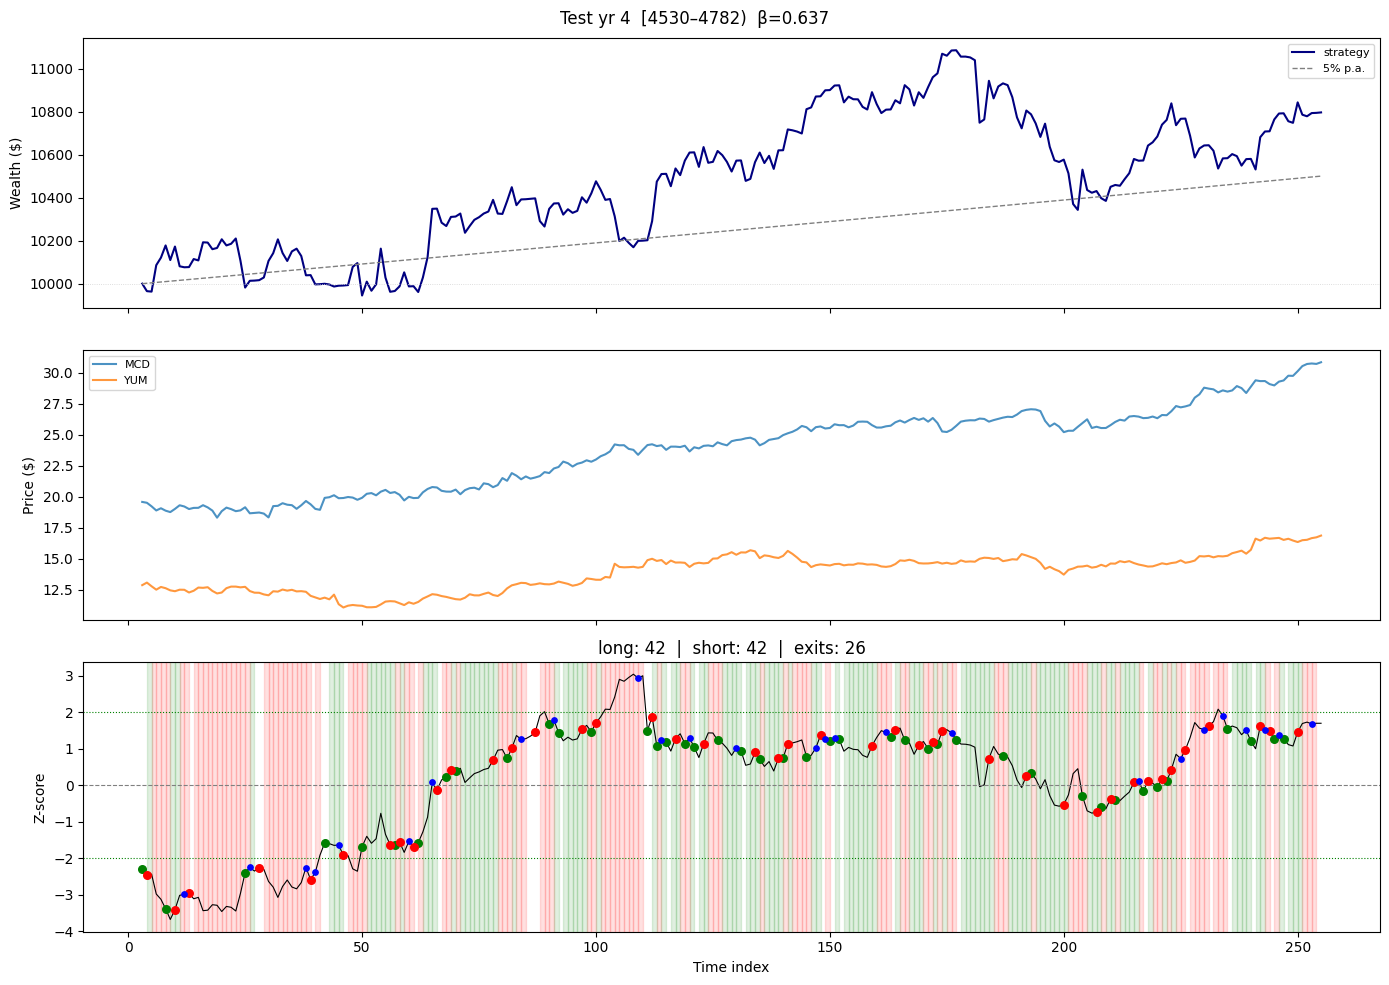

Test yr 5  [4782–5029)  β=0.650                     final $    8193  ret  -18.1%  Sharpe -2.24  MDD  -18.4%


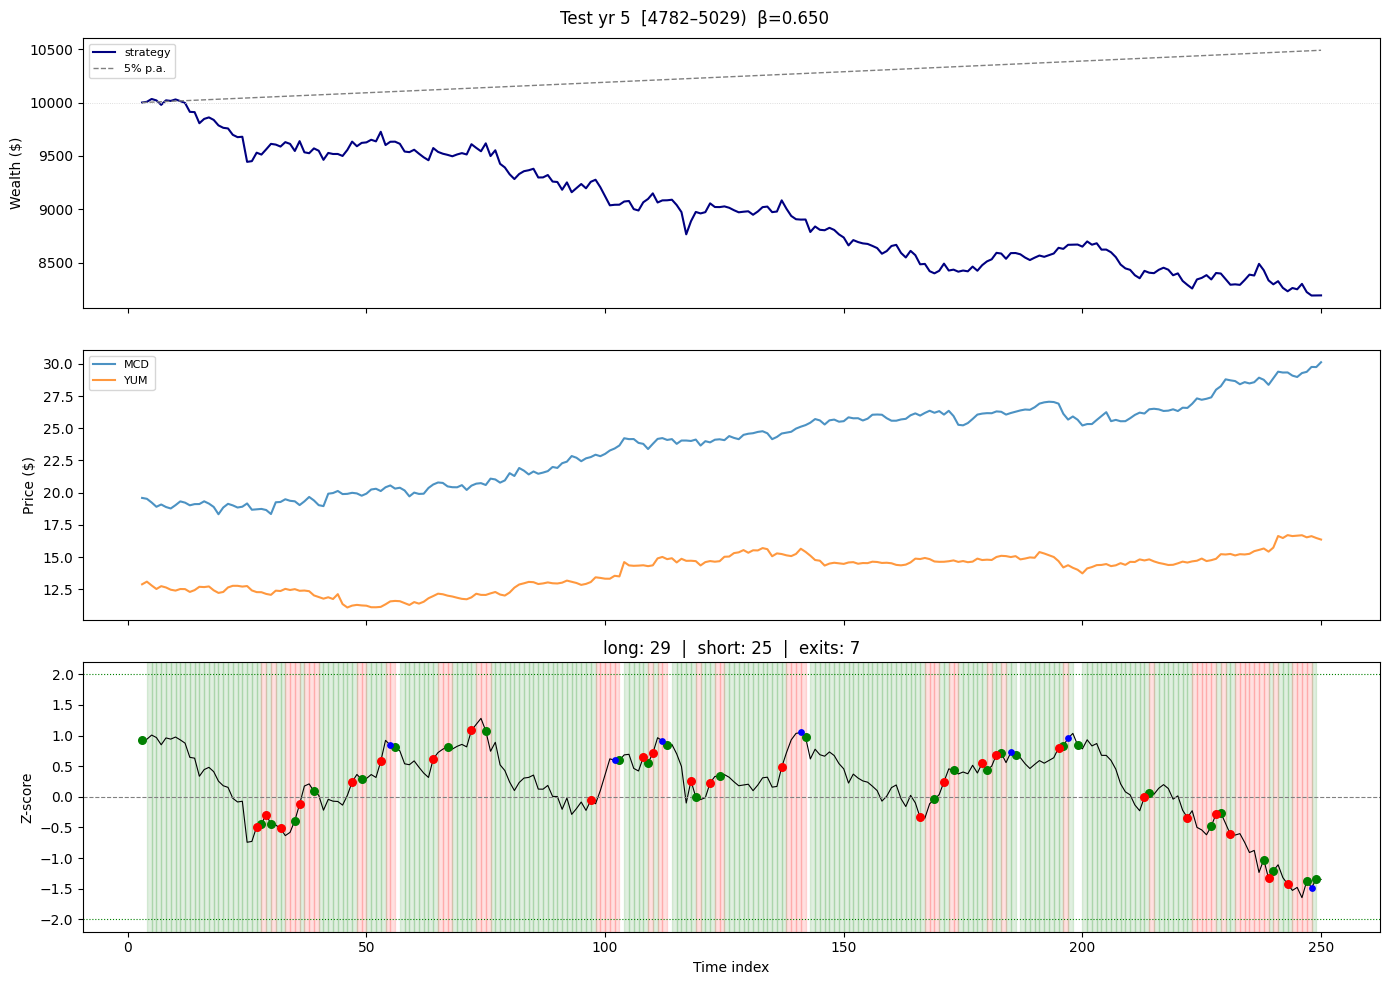

In [11]:
# ── Evaluation — 5 disjoint test windows, each ~1 year ───────────────────
print('=== Test set (5 × 252-bar windows, Kalman beta) ===')

for k in range(5):
    t0     = train_end + k * EPISODE_LEN
    ep_len = min(EPISODE_LEN, N - t0 - 3)
    if ep_len <= 0:
        break

    b, icp, zm, zs = fit_window_kf(t0)
    test_env = PairTradingEnv(
        prices      = prices[:, t0 : t0 + ep_len + 3],
        beta        = b, intercept = icp,
        z_mean      = zm, z_std = zs,
        episode_len = ep_len,
    )

    res   = evaluate(test_env, agent)
    label = f'Test yr {k+1}  [{t0}–{t0+ep_len})  β={b:.3f}'
    metrics(res['wealth'], label)
    plot_results(res, title=label)


=== Training windows ===
Train window 1  t0=252  β=0.823                     final $   11684  ret  +16.8%  Sharpe  1.34  MDD   -9.2%


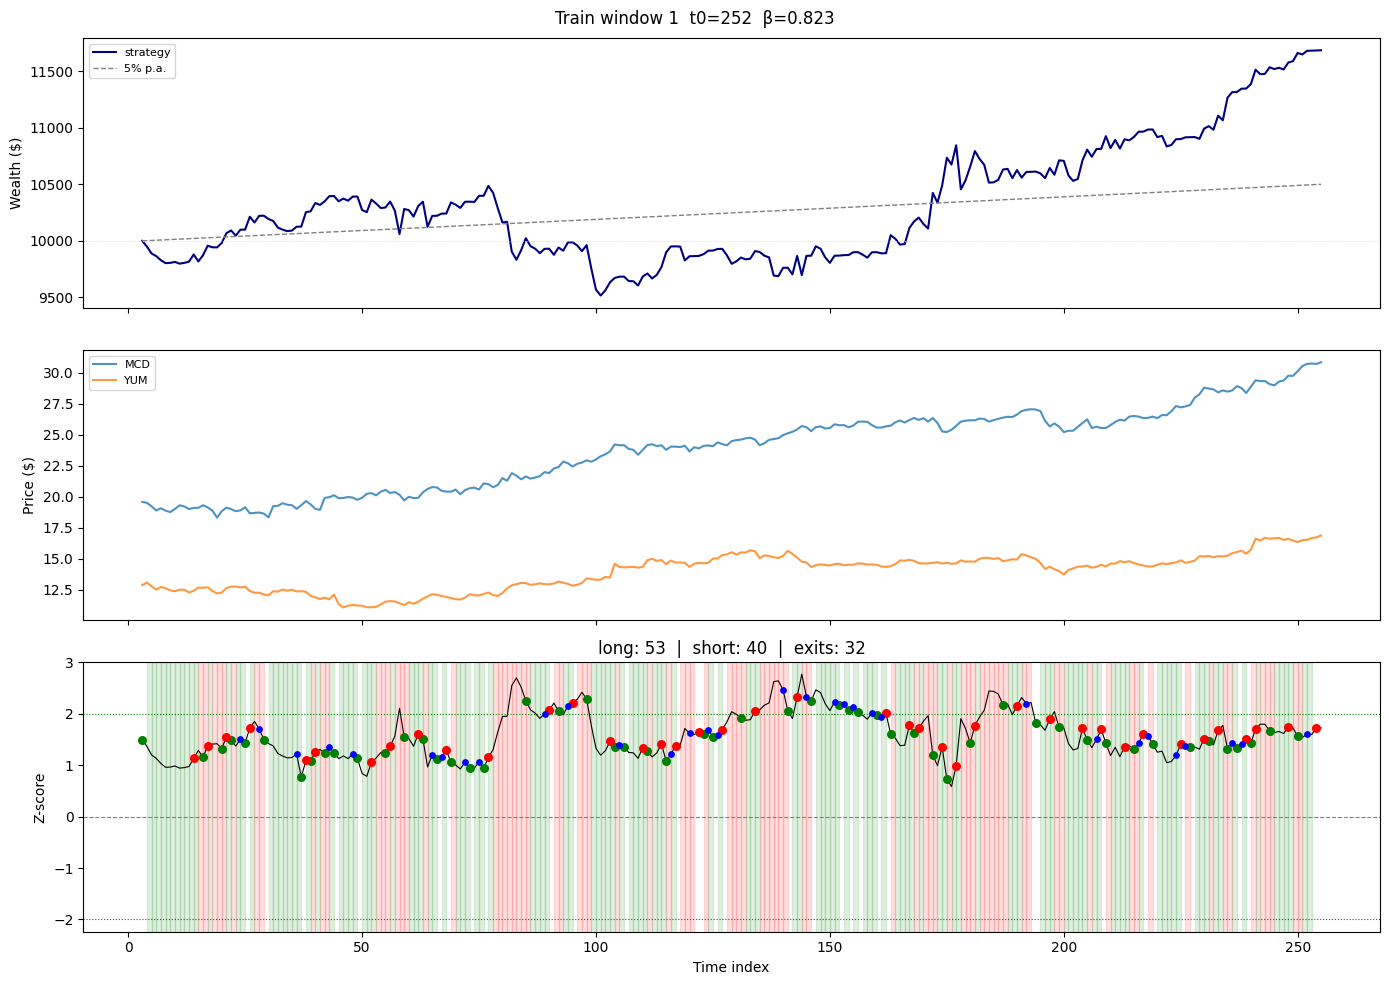

Train window 2  t0=1068  β=0.560                    final $   11853  ret  +18.5%  Sharpe  2.32  MDD   -4.1%


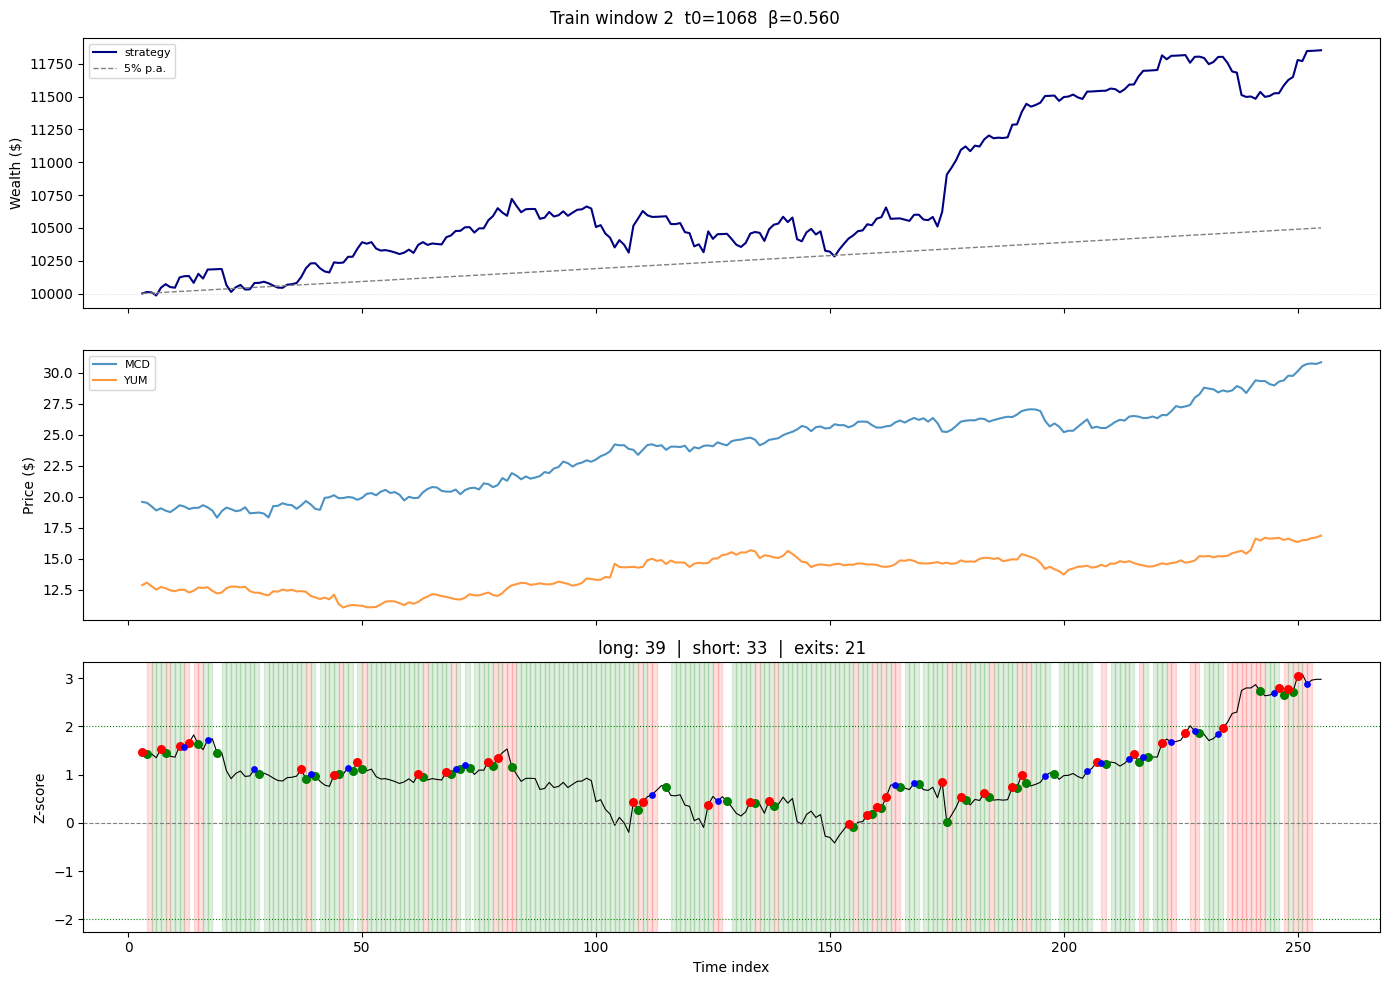

Train window 3  t0=1884  β=0.542                    final $   11019  ret  +10.2%  Sharpe  1.25  MDD   -6.3%


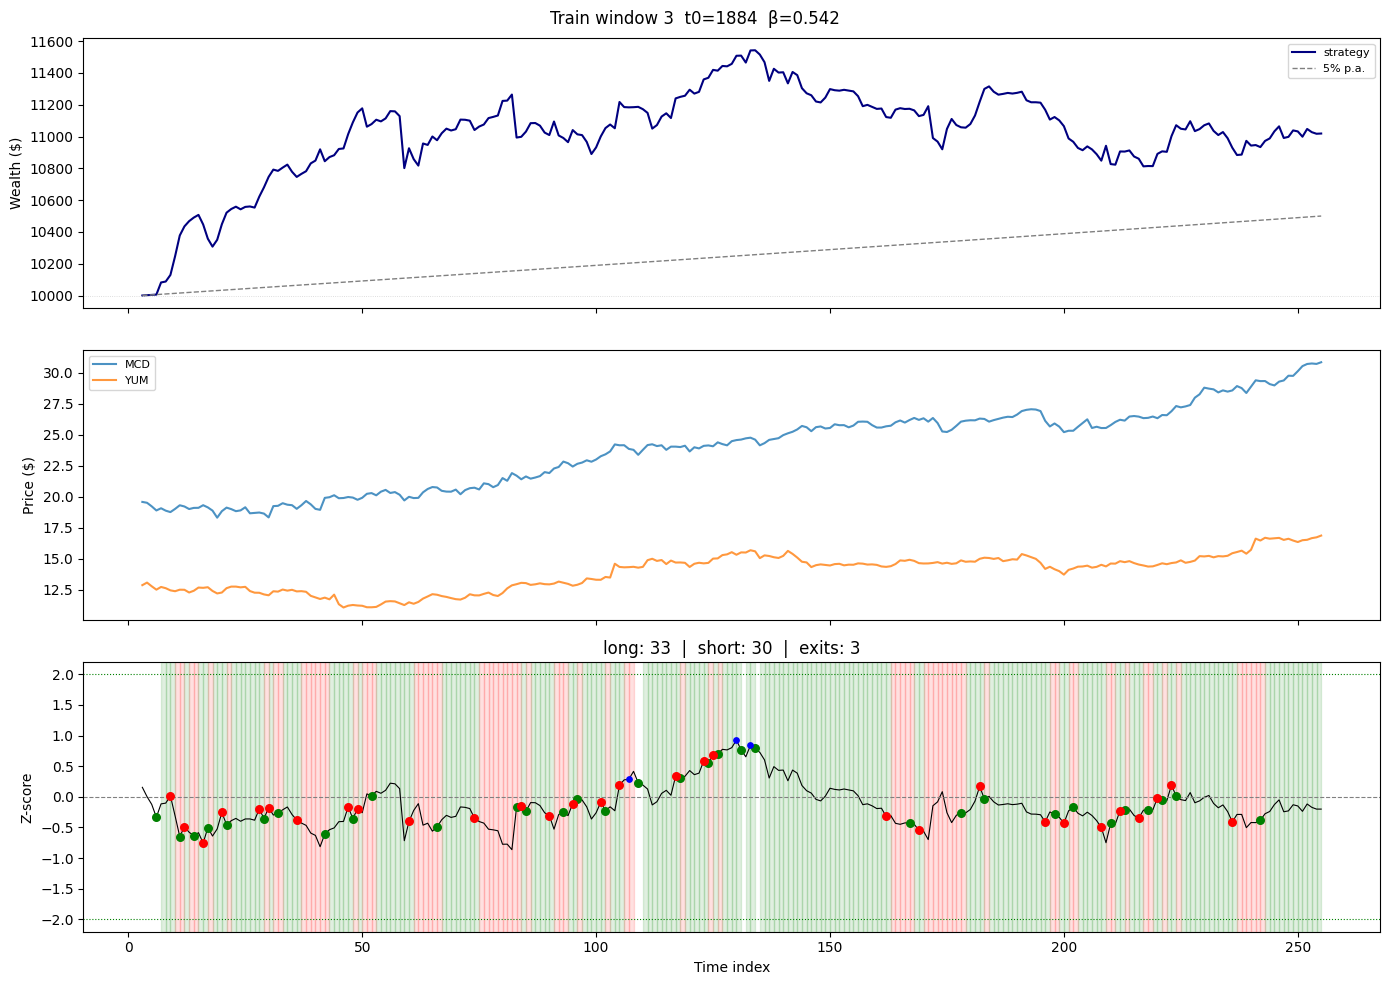

Train window 4  t0=2700  β=0.524                    final $   12689  ret  +26.9%  Sharpe  3.18  MDD   -2.5%


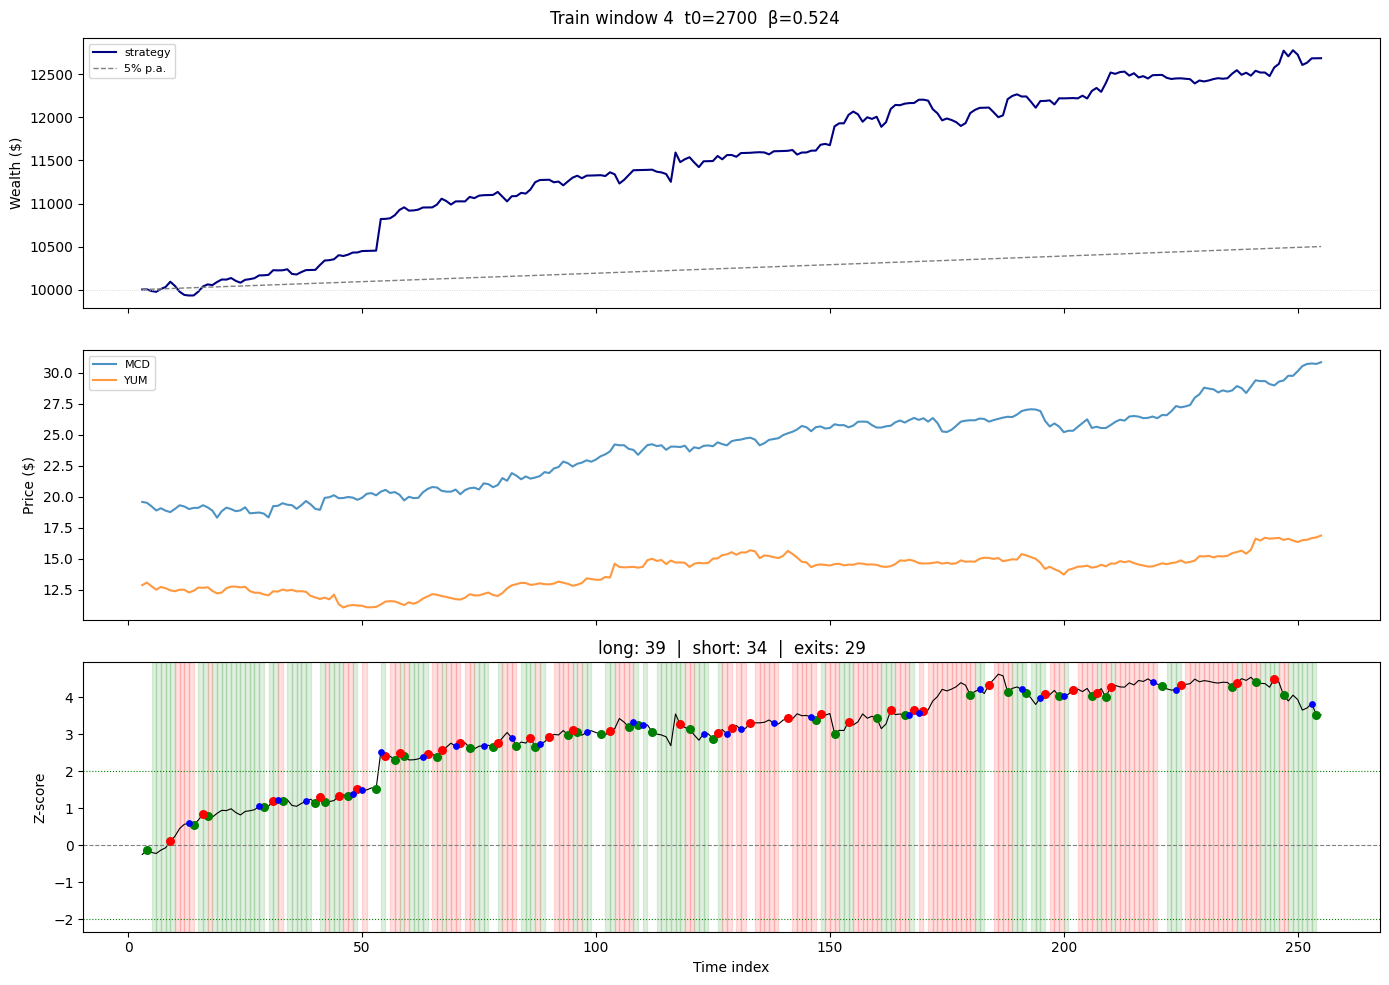

In [12]:
# ── Behaviour on 4 training windows (Kalman beta) ────────────────────────
print('=== Training windows ===')
step = (REAL_T_MAX - REAL_T_MIN) // 4
for k in range(4):
    t0 = REAL_T_MIN + k * step
    b, icp, zm, zs = fit_window_kf(t0)
    env_k = PairTradingEnv(sample_real(t0),
                           beta=b, intercept=icp, z_mean=zm, z_std=zs)
    res_tr = evaluate(env_k, agent)
    label  = f'Train window {k+1}  t0={t0}  β={b:.3f}'
    metrics(res_tr['wealth'], label)
    plot_results(res_tr, title=label)

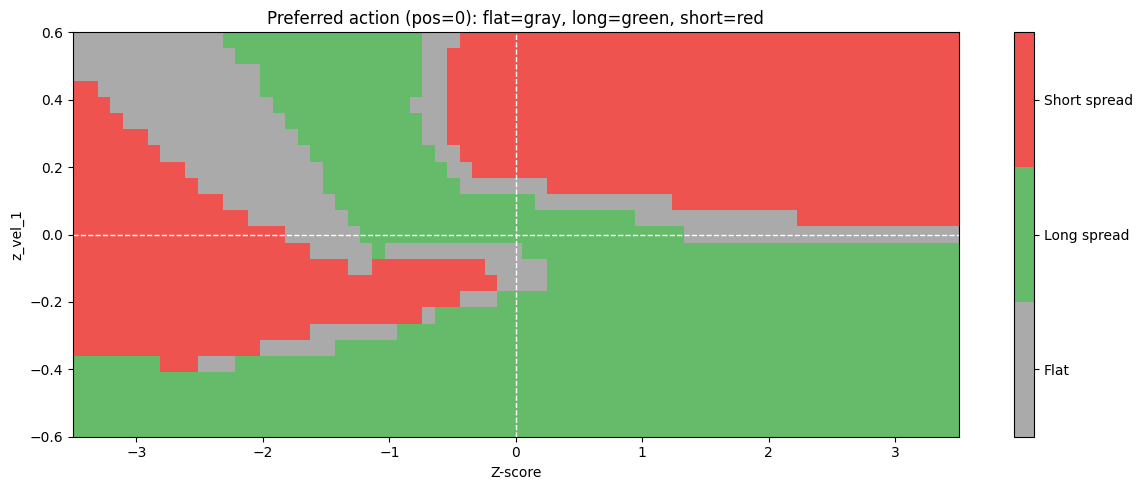

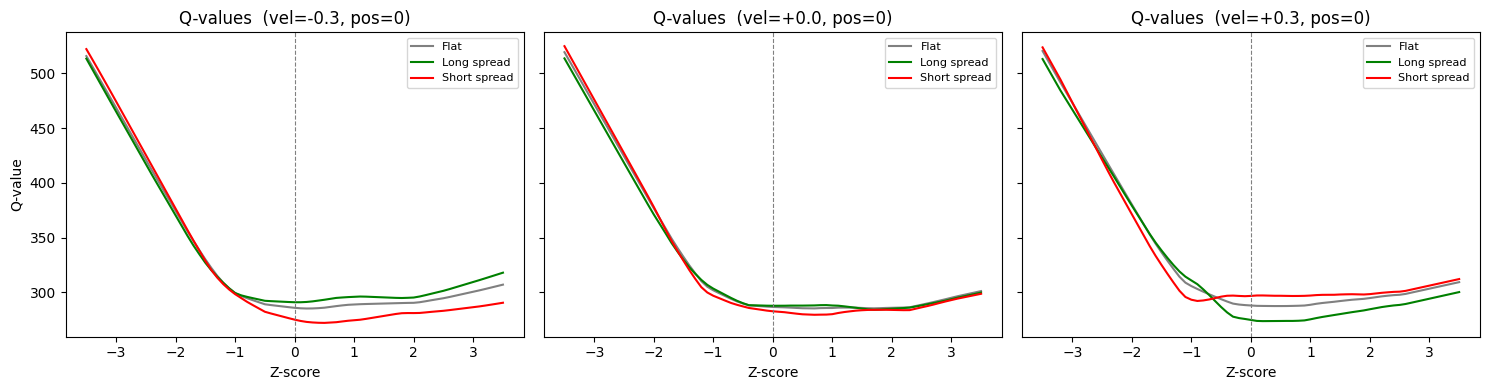

In [13]:
# ── Network interpretation ────────────────────────────────────────────────
ACT_LABELS = ['Flat', 'Long spread', 'Short spread']
ACT_COLORS = ['gray', 'green', 'red']

z_vals   = np.linspace(-3.5, 3.5, 71)
vel_vals = np.linspace(-0.6, 0.6, 25)

agent.q_net.eval()
action_grid = np.zeros((len(vel_vals), len(z_vals)), dtype=int)

with torch.no_grad():
    for i, v in enumerate(vel_vals):
        for j, z in enumerate(z_vals):
            obs = np.array([z, 0.0, v, v * 2.0], dtype=np.float32)
            s   = torch.from_numpy(obs).unsqueeze(0)
            action_grid[i, j] = int(agent.q_net(s).argmax().item())

agent.q_net.train()

cmap = plt.matplotlib.colors.ListedColormap(['#aaaaaa', '#66bb6a', '#ef5350'])
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(
    action_grid, aspect='auto', origin='lower', cmap=cmap, vmin=-0.5, vmax=2.5,
    extent=[z_vals[0], z_vals[-1], vel_vals[0], vel_vals[-1]],
)
ax.set_xlabel('Z-score')
ax.set_ylabel('z_vel_1')
ax.set_title('Preferred action (pos=0): flat=gray, long=green, short=red')
ax.axvline(0, color='white', lw=1, ls='--')
ax.axhline(0, color='white', lw=1, ls='--')
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2])
cbar.set_ticklabels(ACT_LABELS)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, v_fix in zip(axes, [-0.3, 0.0, 0.3]):
    q_vals = np.zeros((len(z_vals), 3))
    with torch.no_grad():
        for j, z in enumerate(z_vals):
            obs = np.array([z, 0.0, v_fix, v_fix * 2.0], dtype=np.float32)
            s   = torch.from_numpy(obs).unsqueeze(0)
            q_vals[j] = agent.q_net(s).numpy()[0]
    for k, (lbl, col) in enumerate(zip(ACT_LABELS, ACT_COLORS)):
        ax.plot(z_vals, q_vals[:, k], label=lbl, color=col, lw=1.5)
    ax.axvline(0, color='gray', lw=0.8, ls='--')
    ax.set_xlabel('Z-score')
    ax.set_title(f'Q-values  (vel={v_fix:+.1f}, pos=0)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Q-value')
plt.tight_layout()
plt.show()

In [14]:
import os
os.makedirs('../models', exist_ok=True)
agent.save('../models/mcd_yum_ddqn_v8.pt')
print('Model saved.')

Model saved.
